Reference: https://www.10xgenomics.com/analysis-guides/xenium-downstream-analysis-in-python-tutorial

This notebook continues from `01_Xenium_5k_data_analysis_journey_python.ipynb` (Section 2.4): downstream analysis of the count matrix (QC, normalization, clustering, marker genes).

In [20]:
# Import the python packages. Rerun this code again if you encounter an error on xarray_schema.
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import spatialdata as sd
import spatialdata_plot

%load_ext autoreload
%autoreload 2

warnings.filterwarnings("ignore")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
sdata = sd.SpatialData.read("../../data/spatialdata/xenium_prime_5k.zarr")

no parent found for <ome_zarr.reader.Label object at 0x75d6444904d0>: None
no parent found for <ome_zarr.reader.Label object at 0x75d64448b650>: None


### 2.4 Downstream analysis of count matrix (sdata['table'])

The first step is QC to remove cells with low transcript counts. We plot the distribution of transcript counts per cell to pick a cutoff (subjective, no gold-standard rule).

We shallow-copy with `adata = sdata['table']` — changes to `adata` are reflected in `sdata['table']`. To keep a separate copy, use `adata = sdata['table'].copy()`.

In [22]:
adata = sdata["table"]
# We keep the raw counts in a layer for later use
adata.layers["counts"] = adata.X.copy()

Text(0, 0.5, 'Number of cells')

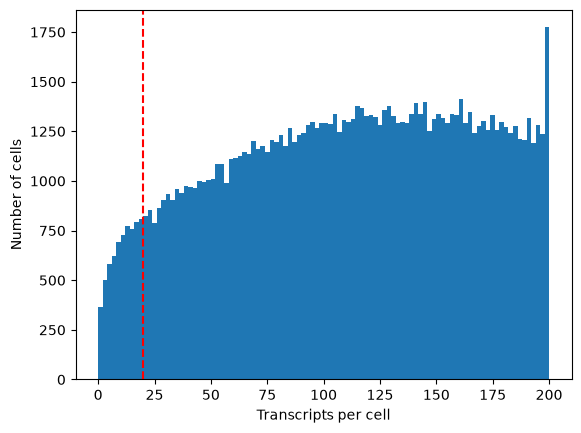

In [23]:
# Visualize the per-cell transcript count distribution to choose a QC cutoff
fig = plt.hist(adata.obs["total_counts"], range=(0, 200), bins=100)
plt.axvline(x=20, color="r", linestyle="--")  # Adjust the cutoff based on the histogram

plt.xlabel("Transcripts per cell")
plt.ylabel("Number of cells")

In [24]:
# Based on the histogram above, we use 20 transcripts as the lower cutoff
thres = np.quantile(adata.obs["total_counts"], 0.98)
sc.pp.filter_cells(adata, min_counts=20)
sc.pp.filter_cells(adata, max_counts=thres)

# We also filter out genes that are rarely expressed
sc.pp.filter_genes(adata, min_cells=100)

In [25]:
%%time
# This is a Xenium Prime panel (>5k genes), so we can find the top 2k highly variable genes
sc.pp.highly_variable_genes(adata, flavor="seurat_v3", n_top_genes=2000)

CPU times: user 4.65 s, sys: 424 ms, total: 5.08 s
Wall time: 2.42 s


In [26]:
%%time
# Log Normalization
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
adata.layers["lognorm"] = adata.X.copy()

CPU times: user 2.84 s, sys: 366 ms, total: 3.21 s
Wall time: 1.96 s


In [27]:
%%time
# We don't center the data here since PCA handles centering, keeping X sparse for memory efficiency
sc.pp.scale(adata, zero_center=False, max_value=10)

CPU times: user 3.82 s, sys: 420 ms, total: 4.24 s
Wall time: 717 ms


In [28]:
%%time
# PCA for dimension reduction, followed by UMAP/neighbors for downstream analysis
sc.pp.pca(adata, n_comps=30)
sc.pp.neighbors(adata, metric="cosine")

# igraph flavor scales better on larger Xenium datasets. Resolution controls the number of clusters
sc.tl.leiden(adata, flavor="igraph", n_iterations=-1, resolution=0.5)

CPU times: user 5min 23s, sys: 2.75 s, total: 5min 26s
Wall time: 5min 13s


In [29]:
%%time
# Can take a while on the full sample
sc.tl.umap(adata)

CPU times: user 1h 15min 19s, sys: 11.9 s, total: 1h 15min 31s
Wall time: 9min 14s


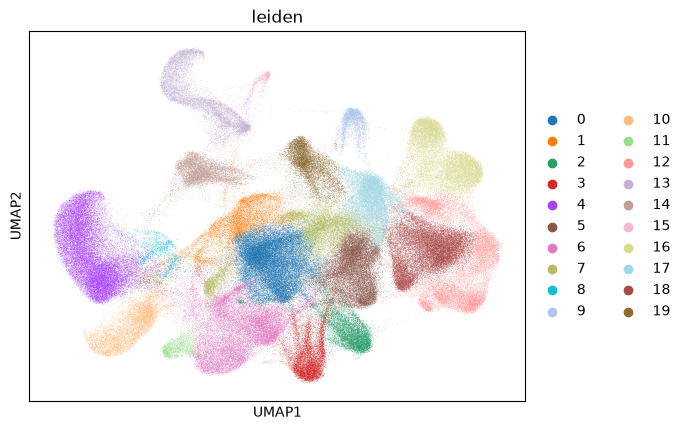

In [30]:
# Visualize the Leiden clusters on the UMAP embedding
sc.pl.umap(adata, color="leiden")

#### Plot clustering results spatially in the slide

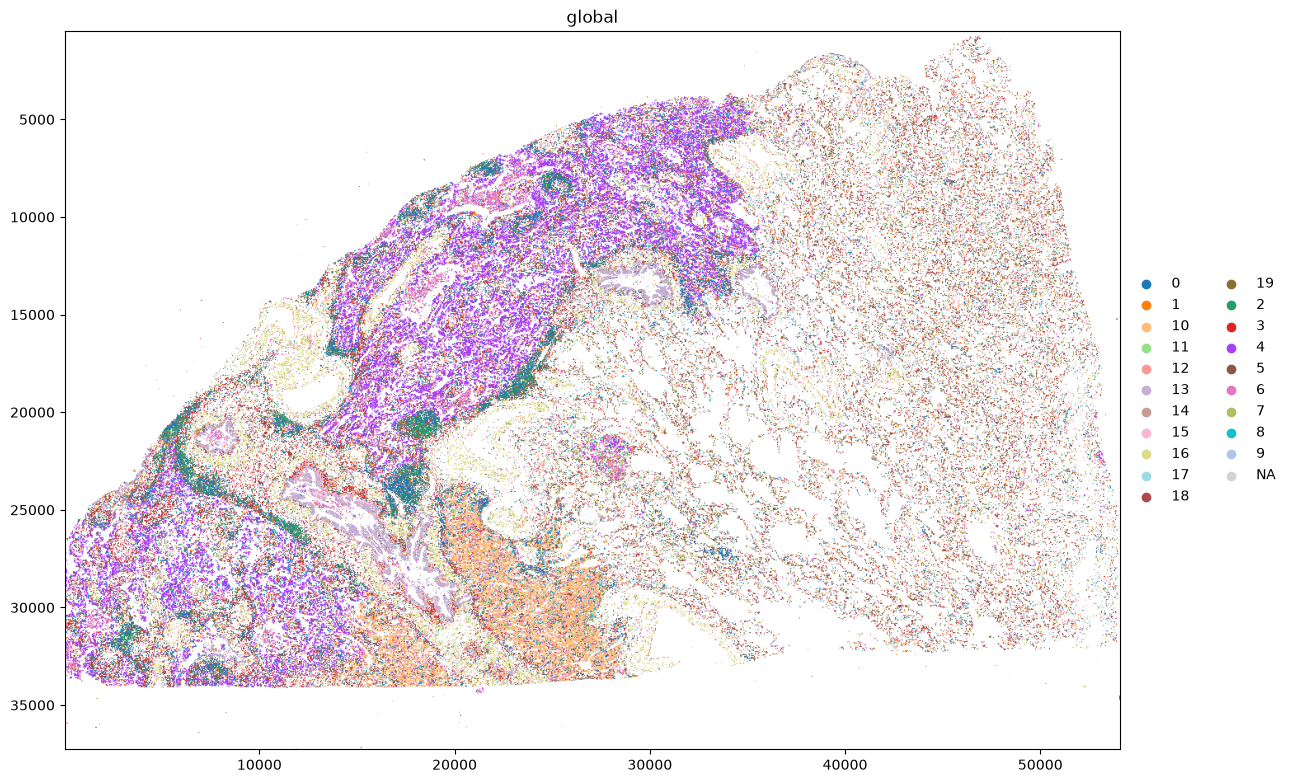

In [31]:
# Re-link the table to cell_boundaries so Leiden clusters can be rendered spatially
sdata.tables["table"].obs["region"] = "cell_boundaries"
sdata.set_table_annotates_spatialelement("table", region="cell_boundaries")

sdata.pl.render_shapes("cell_boundaries", color="leiden").pl.show(figsize=(12.8, 9.6))

#### Export clustering results (for napari / Xenium Explorer)

Save clustering results in a CSV file with two columns — `cell_id` and `group`.

In [32]:
# Export cell_id/cluster pairs so results can be loaded back into napari or Xenium Explorer
clustering_res = adata.obs[["cell_id", "leiden"]]
clustering_res.columns = ["cell_id", "group"]
clustering_res.to_csv("../../results/xenium_5k/clustering/xenium_prime_5k_clustering.csv", index=False)
clustering_res.head()

,cell_id,group
aaaaadnb-1,aaaaadnb-1,0
aaaabalp-1,aaaabalp-1,0
aaaadfei-1,aaaadfei-1,1
aaaadjia-1,aaaadjia-1,0
aaaafglb-1,aaaafglb-1,1


#### Find marker genes for each cluster

`sc.tl.rank_genes_groups` finds marker genes per cluster. `pts=True` also returns the percentage of cells expressing each gene. It expects log-normalized data, so we use `layer="lognorm"`.

In [33]:
# Compute differentially expressed marker genes for each Leiden cluster
sc.tl.rank_genes_groups(adata, groupby="leiden", layer="lognorm", pts=True)

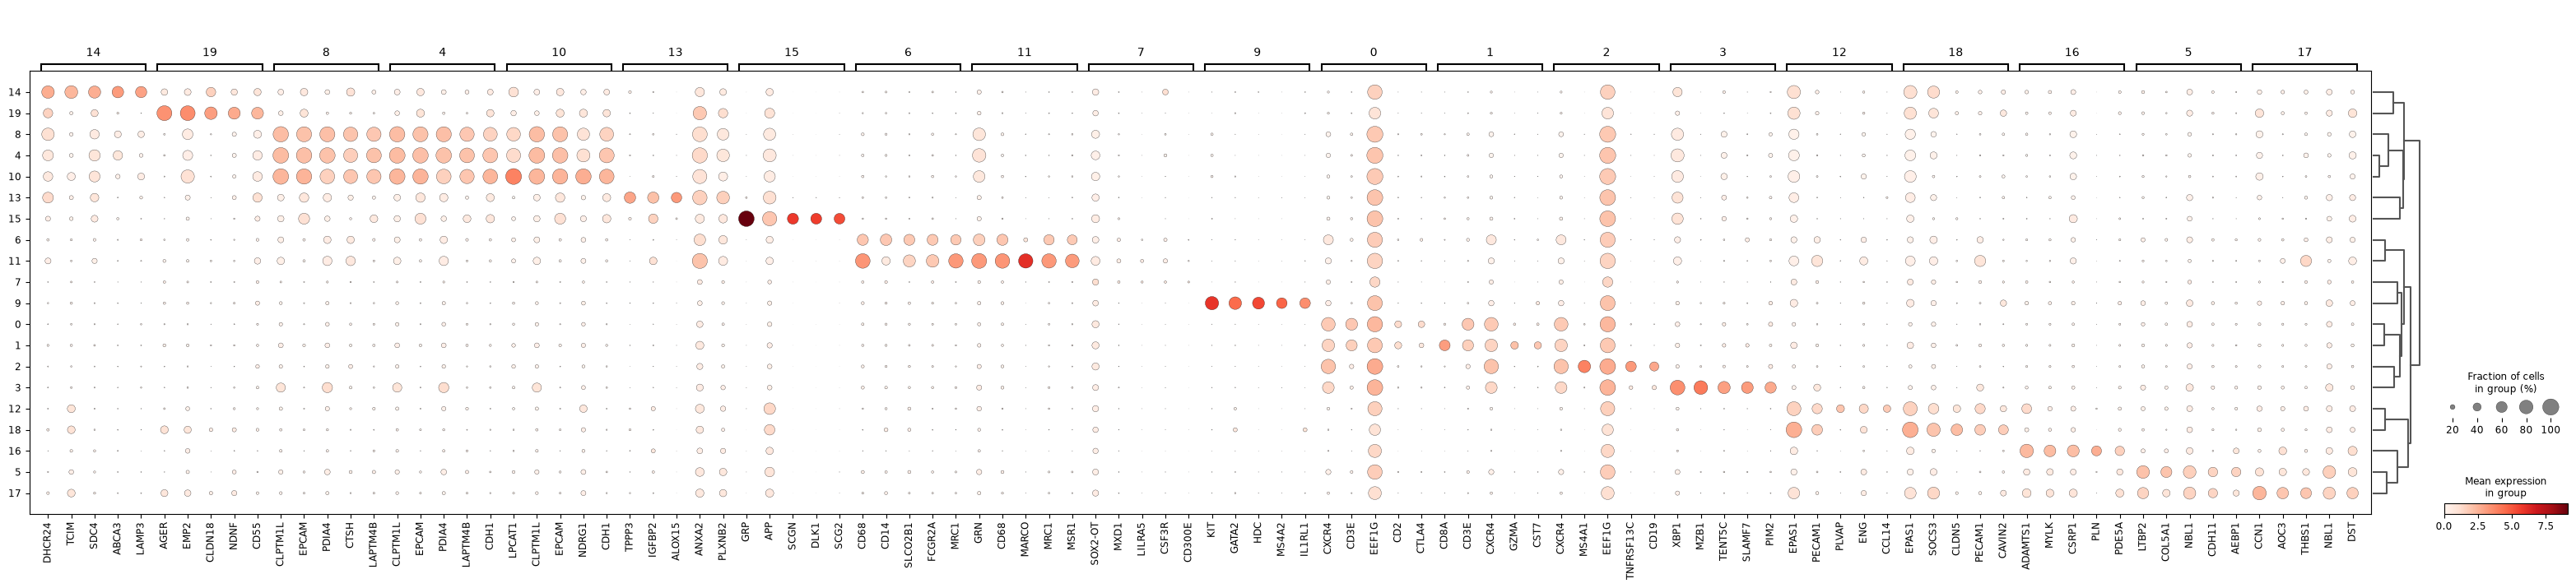

In [34]:
# Dotplot of the top 5 marker genes per cluster
sc.pl.rank_genes_groups_dotplot(adata, n_genes=5)

#### Cell annotation based on marker genes in each cluster

Based on the marker genes above, annotate each cluster:

1. Get the marker genes for a cluster.
2. Find associated cell types via a third-party tool, e.g. [Enrichr](https://maayanlab.cloud/Enrichr/).
3. Confirm cell identity using spatial location in napari (together with the H&E image if available).

Below is a template for pulling the full marker gene table for a single cluster — replace `"0"` with the cluster you're investigating.

In [35]:
# Pull the full ranked marker gene table for a single cluster (edit group id as needed)
cluster_markers = sc.get.rank_genes_groups_df(adata, group="0")
cluster_markers.head(10)

,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
0,CXCR4,212.362320,3.017723,0.0,0.0,0.797112,0.239101
1,CD3E,191.490143,4.065363,0.0,0.0,0.666677,0.079164
2,EEF1G,120.928795,0.975541,0.0,0.0,0.928146,0.836647
3,CD2,99.916603,3.807193,0.0,0.0,0.318347,0.032474
4,CTLA4,96.082680,4.062224,0.0,0.0,0.300344,0.032304
5,CD44,93.627914,1.380983,0.0,0.0,0.573604,0.377878
6,ITGAL,92.580574,2.836432,0.0,0.0,0.326197,0.072481
7,IL2RG,91.974373,2.744182,0.0,0.0,0.328341,0.076678
8,CCR4,90.593658,4.695188,0.0,0.0,0.257338,0.015371
9,IKZF1,90.178772,2.727143,0.0,0.0,0.317558,0.070626


#### Saving the processed data

We save the processed Zarr store for further use in Section 3.

In [36]:
# Save the processed SpatialData (with QC, clustering, etc.) for reuse in Section 3
sdata.write("../../data/xenium_prime_5k_processed.zarr", overwrite=True)

#### Export lightweight visualization dataset (for local napari)

Export a small subset of cell-level data (coordinates, boundaries, cluster labels) so we don't need to transfer the full Zarr store to the local desktop for viewing in napari.

In [37]:
import os

viz_dir = "../../results/xenium_5k/visualization"
os.makedirs(viz_dir, exist_ok=True)

In [38]:
# Export cell centroid coordinates
coords = pd.DataFrame(adata.obsm["spatial"], columns=["x", "y"])
coords.insert(0, "cell_id", adata.obs["cell_id"].values)
coords.to_parquet(f"{viz_dir}/cell_coordinates.parquet", index=False)
coords.head()

,cell_id,x,y
0,aaaaadnb-1,822.469055,5111.537598
1,aaaabalp-1,843.901428,5149.261230
2,aaaadfei-1,831.219421,5133.179199
3,aaaadjia-1,839.742981,5159.693848
4,aaaafglb-1,784.250916,5143.785645


In [39]:
# Export cell boundary polygons, subset to the cells that survived QC filtering
cell_boundaries = sdata.shapes["cell_boundaries"]
cell_boundaries = cell_boundaries.loc[cell_boundaries["cell_id_str"].isin(adata.obs["cell_id"])]
cell_boundaries = cell_boundaries.set_index("cell_id_str")
cell_boundaries.to_parquet(f"{viz_dir}/cell_boundaries.parquet")

In [40]:
# Export cluster labels
cluster_labels = adata.obs[["cell_id", "leiden"]].rename(columns={"leiden": "group"})
cluster_labels.to_csv(f"{viz_dir}/cluster_labels.csv", index=False)
cluster_labels.head()

,cell_id,group
aaaaadnb-1,aaaaadnb-1,0
aaaabalp-1,aaaabalp-1,0
aaaadfei-1,aaaadfei-1,1
aaaadjia-1,aaaadjia-1,0
aaaafglb-1,aaaafglb-1,1


In [41]:
# Sanity check: all three exports should reference the same set of cells
assert len(coords) == len(cluster_labels) == len(cell_boundaries)
assert set(coords["cell_id"]) == set(cluster_labels["cell_id"]) == set(cell_boundaries.index)